# Auto Scout Project

**Author:** Mark Joslin

**GitHub:** [link](https://github.com/mjoslin-ai/Magnimind-Project-Auto-Scout)

**Phase 3:** Outlier Analysis

## Table of Contents

* Objective
* Libraries
* Import Data
* Helper Functions
* Missing Value Analysis
* Export Data

## Objective

Clean and preprocess a 2019 online vehicle dataset (≈15,919 rows, 54 columns, 9 car models) containing many inconsistent, broken, and messy values, so it becomes suitable for machine learning. The project is broken up into four main phases: 

1. Data Cleaning: 
    * Removing broken, irrelevant, or redundant columns
    * Creating new columns with clean, meaningful, and usable values
2. Missing Value Analysis:
    * Filling in the gabs where data is missing
    * With techniques such as mean, median, or mode
3. Outlier Analysis:
    * Outliers are detected and visualized using boxplots and histograms.
    * Rather than removing all outliers (since extreme but valid values are expected for certain car models, e.g. luxury vehicles with high prices or powerful engines), the focus is on identifying and addressing only clear misprints or logically inconsistent entries.
4. Dummy Variable Analysis:
    * Categorical and multi-label columns (e.g. Comfort_Convenience, Extras) are converted to numeric format to create binary indicator variables suitable for machine learning.
    * Key techniques include pd.get_dummies() and str.get_dummies(sep=",")

This notebook covers Phase 3 Outlier Analysis with input from phase2_cleaned_data.csv (15919 rows, 34 columns) and output phase3_cleaned_data.csv.

## Libraries

In [741]:
import pandas as pd
import numpy as np
import seaborn as sns
import warnings
warnings.filterwarnings("ignore", category=SyntaxWarning)

## Import Data

In [742]:
df_org = pd.read_csv("data/phase2_cleaned_data.csv")
df = df_org.copy()
df.head(3).T

,0,1,2
make_model,Audi A1,Audi A1,Audi A1
body_type,Sedans,Sedans,Sedans
price,15770,14500,14640
vat,VAT deductible,Price negotiable,VAT deductible
km,56013.0,80000.0,83450.0
previous_owners,2.0,1.0,1.0
next_inspection,2021-06,2021-03,2020-02
inspection_new,Yes,No,No
body_color,Black,Red,Black
paint_type,metallic,metallic,metallic


In [743]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15919 entries, 0 to 15918
Data columns (total 34 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   make_model            15919 non-null  str    
 1   body_type             15919 non-null  str    
 2   price                 15919 non-null  int64  
 3   vat                   15919 non-null  str    
 4   km                    15919 non-null  float64
 5   previous_owners       15919 non-null  float64
 6   next_inspection       15919 non-null  str    
 7   inspection_new        15919 non-null  str    
 8   body_color            15919 non-null  str    
 9   paint_type            15919 non-null  str    
 10  nr_of_doors           15919 non-null  float64
 11  nr_of_seats           15919 non-null  float64
 12  gearing_type          15919 non-null  str    
 13  cylinders             15919 non-null  float64
 14  drive_chain           15919 non-null  str    
 15  fuel                  15919 no

In [744]:
def count_outliers(col):
    if not pd.api.types.is_numeric_dtype(col):
        return 0
    q1 = col.quantile(0.25)
    q3 = col.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return ((col < lower) | (col > upper)).sum()

outlier_df = (
    df.apply(count_outliers)
      .to_frame('outlier_count')
      .query('outlier_count > 0')
      .reset_index(names='column')
)

print(outlier_df.sort_values('outlier_count', ascending=False))

                  column  outlier_count
5              cylinders           2993
2        previous_owners           2563
4            nr_of_seats           1611
9        warranty_months            905
1                     km            699
0                  price            479
8                  hp_kw            431
14    emissions_g_co2/km            292
13   country_l_per_100km            258
6                  gears            236
3            nr_of_doors            221
11  combined_l_per_100km            106
10             weight_kg             78
12      city_l_per_100km             64
7        displacement_cc             24


## Helper Functions

In [745]:
def get_outliers(column, return_type="outliers"):
    Q1 = column.quantile(0.25)
    Q3 = column.quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    if return_type == "outliers":
        return column[(column < lower_bound) | (column > upper_bound)]
    elif return_type == "lower":
        return column[column >= lower_bound].min()
    elif return_type == "upper":
        return column[column <= upper_bound].max()
    else:
        raise ValueError("return_type must be 'outliers', 'lower', or 'upper'")
    

def nullify_invalid_values(df, target_column, invalid_map):
    # domain knowledge based outlier removal
    # Create a copy of the specific column so we don't touch the original df
    new_series = df[target_column].copy()
    
    for model, values in invalid_map.items():
        # Handle both single values and lists
        to_remove = values if isinstance(values, list) else [values]
        
        # Identify rows where the model matches AND the value is invalid
        mask = (df['make_model'] == model) & (new_series.isin(to_remove))
        
        # Update the copy, not the original
        new_series.loc[mask] = np.nan
        
    return new_series

## Outlier Analysis

### make_model

In [746]:
df['make_model'].value_counts(dropna=False)

make_model
Audi A3           3097
Audi A1           2614
Opel Insignia     2598
Opel Astra        2526
Opel Corsa        2219
Renault Clio      1839
Renault Espace     991
Renault Duster      34
Audi A2              1
Name: count, dtype: int64

Audi A2 stopped production in 2005

In [747]:
df.drop(df[df['make_model'] == 'Audi A2'].index, inplace=True)

In [748]:
df['make_model'].value_counts(dropna=False)

make_model
Audi A3           3097
Audi A1           2614
Opel Insignia     2598
Opel Astra        2526
Opel Corsa        2219
Renault Clio      1839
Renault Espace     991
Renault Duster      34
Name: count, dtype: int64

### cylinders

<Axes: xlabel='cylinders', ylabel='make_model'>

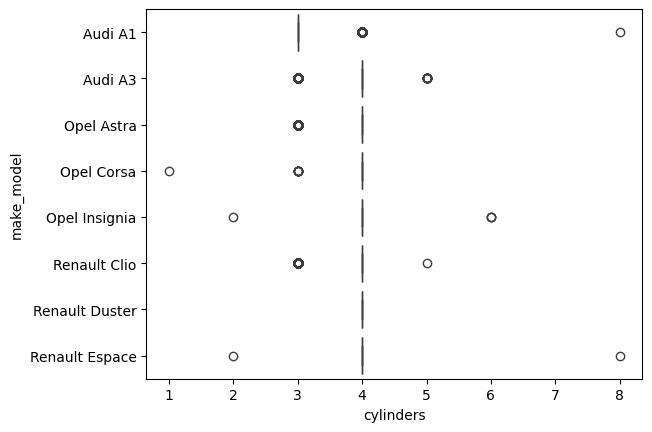

In [749]:
sns.boxplot(data=df, x='cylinders', y='make_model')

In [750]:
invalid_cylinders = {
    'Audi A1': 8,
    'Audi A3': 5,
    'Opel Corsa': 1,
    'opel insignia': [2,6],
    'Renault Clio': 5,
    'Renault Espace': [2,8],
}

cy = nullify_invalid_values(df, 'cylinders', invalid_cylinders)



In [751]:
cy.isna().sum()

np.int64(26)

In [752]:
cy = cy.fillna(df.groupby(['make_model', 'body_type'])['cylinders'].transform(lambda x: x.mode()[0] if not x.mode().empty else np.nan))

In [753]:
cy.isna().sum()

np.int64(0)

In [754]:
df['cylinders'] = cy

### previous_owners

<Axes: xlabel='previous_owners'>

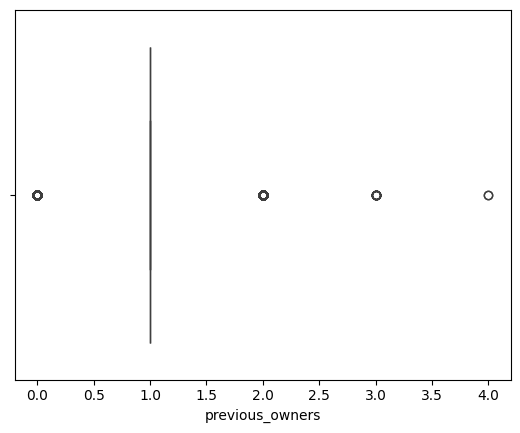

In [755]:
sns.boxplot(data=df, x='previous_owners')

### nr_of_seats

<Axes: xlabel='nr_of_seats', ylabel='make_model'>

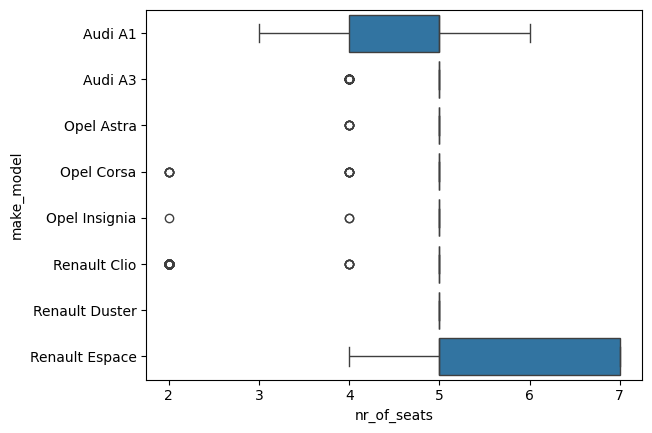

In [756]:
sns.boxplot(data=df, x='nr_of_seats', y='make_model')

In [757]:
#pd.set_option('display.max_rows', None)
#df.groupby(['make_model', 'body_type'])['nr_of_seats'].value_counts()

may or may not be accounting for rear middle seat

In [758]:
invalid_nr_of_seats = {
    'Audi A1': [3,6],
    'Opel Corsa': 2,
    'opel insignia': 2,
    'Renault Clio': 2,
    'Renault Espace': 4,
}

nos = nullify_invalid_values(df, 'nr_of_seats', invalid_nr_of_seats)

In [759]:
nos.isna().sum()

np.int64(121)

In [760]:
nos = nos.fillna(df.groupby(['make_model', 'body_type'])['nr_of_seats'].transform(lambda x: x.mode()[0] if not x.mode().empty else np.nan))

In [761]:
nos.isna().sum()

np.int64(0)

In [762]:
df['nr_of_seats'] = nos

### nr_of_doors

<Axes: xlabel='nr_of_doors', ylabel='make_model'>

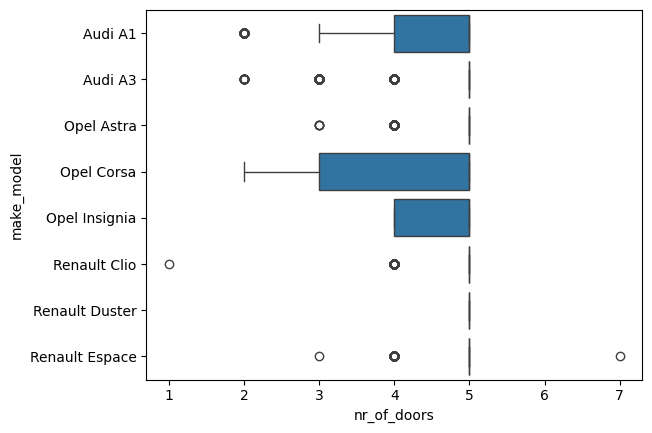

In [763]:
sns.boxplot(data=df, x='nr_of_doors', y='make_model')

may or may not account for rear hatch door

In [764]:
invalid_nr_of_doors = {
    'Renault Clio': 1,
    'Renault Espace': [3,7],
}

nod = nullify_invalid_values(df, 'nr_of_doors', invalid_nr_of_doors)

In [765]:
nod.isna().sum()

np.int64(3)

In [766]:
nod = nod.fillna(df.groupby(['make_model', 'body_type'])['nr_of_doors'].transform(lambda x: x.mode()[0] if not x.mode().empty else np.nan))

In [767]:
nod.isna().sum()

np.int64(0)

In [768]:
df['nr_of_doors'] = nod

### warranty_months

<Axes: xlabel='warranty_months'>

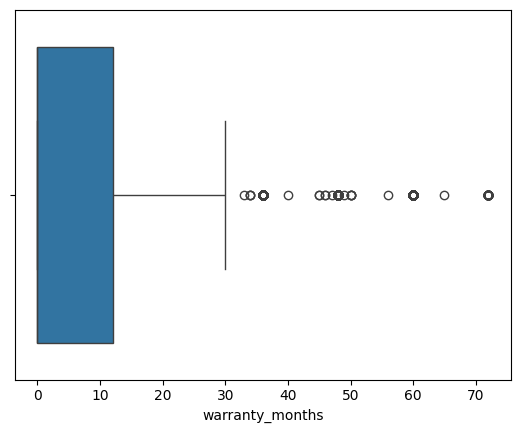

In [769]:
sns.boxplot(data=df, x='warranty_months')

### km

<Axes: xlabel='km'>

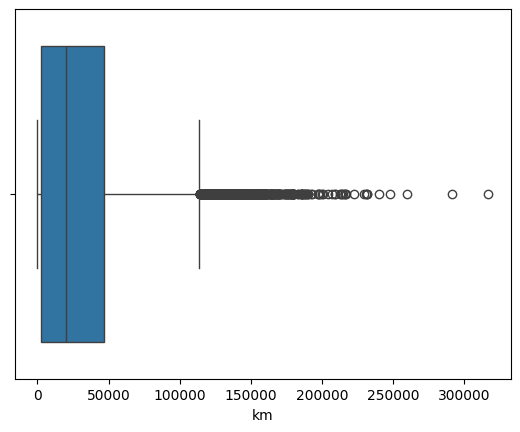

In [770]:
sns.boxplot(data=df, x='km')

### hp_kw

<Axes: xlabel='hp_kw'>

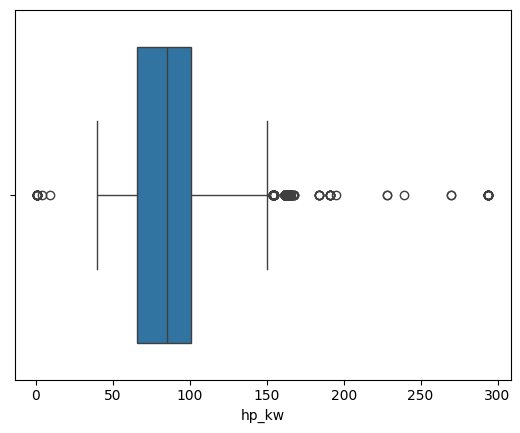

In [771]:
sns.boxplot(data=df, x='hp_kw')

In [772]:
df.loc[df['hp_kw'] < 50, 'hp_kw'] = np.nan

In [773]:
df['hp_kw'].isna().sum()

np.int64(25)

In [774]:
hp = df['hp_kw'].fillna(df.groupby(['make_model', 'fuel', 'displacement_cc'])['hp_kw'].transform(lambda x: x.median()))

In [775]:
hp.isna().sum()

np.int64(3)

In [776]:
hp = hp.fillna(df.groupby(['make_model'])['hp_kw'].transform(lambda x: x.median()))

In [777]:
hp.isna().sum()

np.int64(0)

In [778]:
df['hp_kw'] = hp

### displacement_cc

<Axes: xlabel='displacement_cc', ylabel='make_model'>

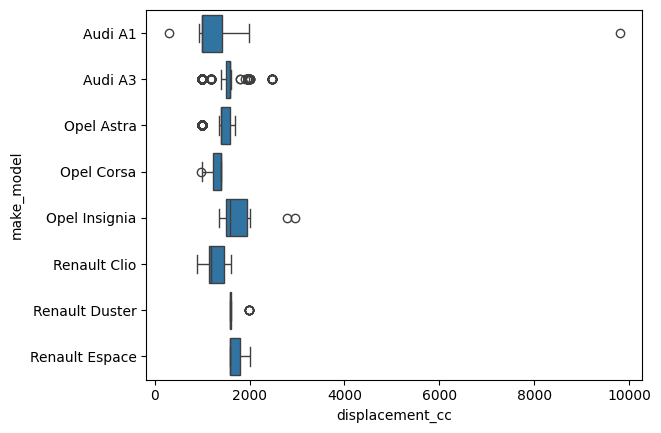

In [779]:
sns.boxplot(data=df, x='displacement_cc', y='make_model')

In [780]:
df.loc[(df['displacement_cc'] < 900) | (df['displacement_cc'] > 2000), 'displacement_cc'] = np.nan

In [781]:
df['displacement_cc'].isna().sum()

np.int64(387)

In [782]:
d = df['displacement_cc'].fillna(df.groupby(['make_model', 'fuel', 'cylinders'])['displacement_cc'].transform(lambda x: x.median()))

In [783]:
d.isna().sum()

np.int64(9)

In [784]:
d = d.fillna(df.groupby(['make_model', 'fuel'])['displacement_cc'].transform(lambda x: x.median()))

In [785]:
d.isna().sum()

np.int64(0)

In [786]:
df['displacement_cc'] = d

### price

<Axes: xlabel='price', ylabel='make_model'>

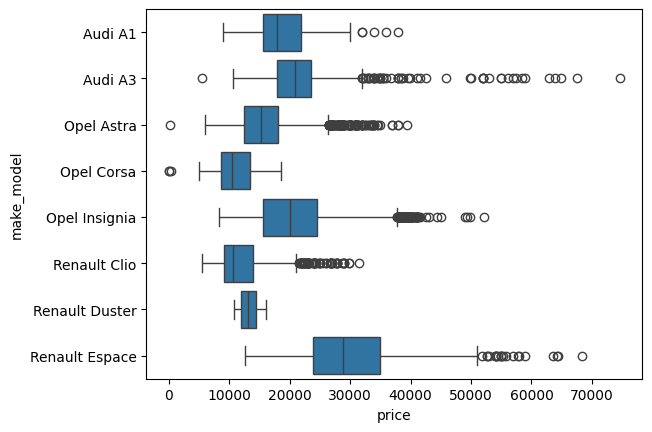

In [787]:
sns.boxplot(data=df, x='price', y='make_model')

low price

In [788]:
price_lower = df.groupby('make_model')['price'].transform(lambda x: get_outliers(x, return_type="lower"))

In [789]:
df.loc[df['price'] < price_lower, 'price'] = np.nan

In [790]:
df['price'].isna().sum()

np.int64(5)

high price 

In [791]:
price_upper = df.groupby('make_model')['price'].transform(lambda x: get_outliers(x, return_type="upper"))

In [792]:
df.loc[(df['price'] > price_upper) & (df['make_model'] == 'Audi A1'), ['make_model', 'body_type', 'price', 'hp_kw', 'displacement_cc', 'km', 'age_years', 'condition']]

,make_model,body_type,price,hp_kw,displacement_cc,km,age_years,condition
707,Audi A1,Sedans,32000.0,85.0,999.0,1.0,0.0,Pre-registered
710,Audi A1,Compact,31990.0,85.0,999.0,10.0,0.0,New
713,Audi A1,Sedans,37900.0,147.0,1984.0,7000.0,0.0,Used
732,Audi A1,Sedans,35900.0,85.0,999.0,200.0,0.0,Pre-registered
733,Audi A1,Sedans,33900.0,85.0,999.0,1.0,1.0,Employee's car


In [793]:
df.loc[(df['price'] > 60000), ['make_model', 'body_type', 'price', 'hp_kw', 'displacement_cc', 'km', 'age_years', 'condition']]

,make_model,body_type,price,hp_kw,displacement_cc,km,age_years,condition
3587,Audi A3,Sedans,64900.0,294.0,1395.0,35000.0,1.0,Used
3590,Audi A3,Sedans,62900.0,294.0,1395.0,700.0,0.0,Used
3595,Audi A3,Station wagon,63900.0,294.0,1395.0,10.0,0.0,Used
3648,Audi A3,Sedans,74600.0,294.0,1395.0,13000.0,1.0,Used
3649,Audi A3,Compact,67600.0,294.0,1395.0,37747.0,2.0,Used
15826,Renault Espace,Van,68320.0,118.0,1598.0,4307.0,0.0,Demonstration
15828,Renault Espace,Van,64332.0,165.0,1798.0,1.0,0.0,New
15831,Renault Espace,Van,64298.0,165.0,1798.0,15.0,0.0,New
15833,Renault Espace,Van,63477.0,147.0,1618.0,8.0,0.0,New


In [794]:
df.loc[(df['price'] > 60000) & (df['km'] > 800), 'price'] = np.nan

In [795]:
df['price'].isna().sum()

np.int64(9)

fill NaN

In [796]:
p = df['price'].fillna(df.groupby(['make_model', 'body_type', 'displacement_cc'])['price'].transform(lambda x: x.median()))

In [797]:
p.isna().sum()

np.int64(0)

In [798]:
df['price'] = p

### gearing_type

<Axes: xlabel='gearing_type', ylabel='make_model'>

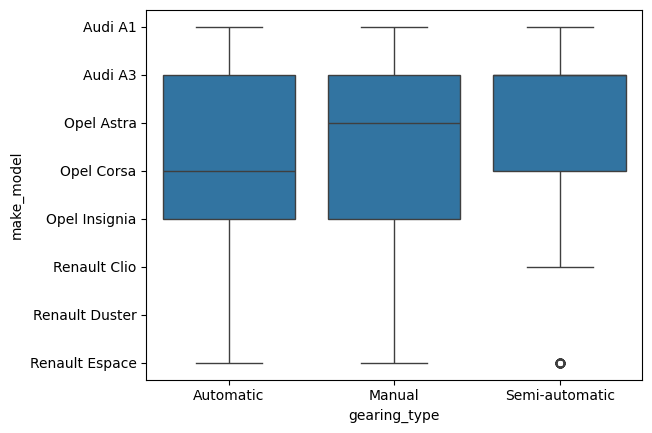

In [799]:
sns.boxplot(data=df, x='gearing_type', y='make_model')

### gears

In [800]:
df.loc[(df['gears'] > 10) | (df['gears'] < 5), 'gears'] = np.nan

<Axes: xlabel='gears', ylabel='make_model'>

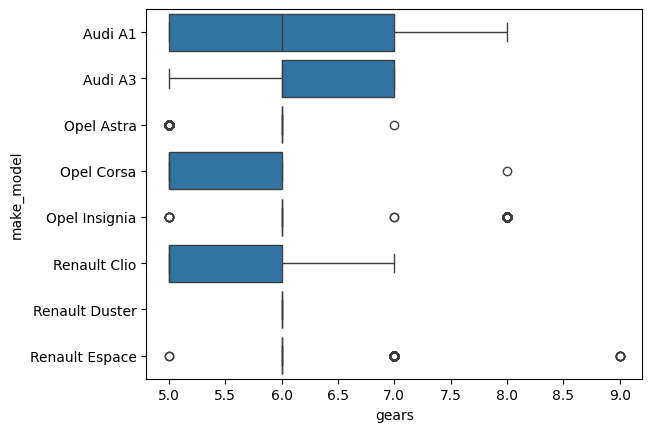

In [801]:
sns.boxplot(data=df, x='gears', y='make_model')

In [802]:
invalid_gears = {
    'Audi A1': 8,
    'Audi A3': 5,
    'Opel Astra': 7,
    'opel insignia': [5,7],
    'Renault Espace': [5,9],
}

g = nullify_invalid_values(df, 'gears', invalid_gears)

In [803]:
g.isna().sum()

np.int64(21)

In [804]:
g = g.fillna(df.groupby(['make_model', 'gearing_type'])['gears'].transform(lambda x: x.mode()[0] if not x.mode().empty else np.nan))

In [805]:
g.isna().sum()

np.int64(0)

In [806]:
df['gears'] = g

### weight_kg

<Axes: xlabel='weight_kg', ylabel='make_model'>

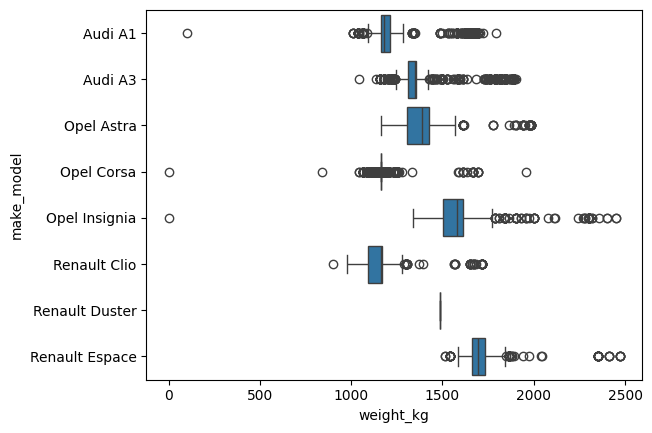

In [807]:
sns.boxplot(data=df, x='weight_kg', y='make_model')

In [808]:
df.loc[(df['weight_kg'] > 2000) | (df['weight_kg'] < 900), 'weight_kg'] = np.nan

In [809]:
df['weight_kg'].isna().sum()

np.int64(58)

In [810]:
w = df['weight_kg'].fillna(df.groupby(['make_model', 'body_type', 'fuel'])['weight_kg'].transform(lambda x: x.median()))

In [811]:
w.isna().sum()

np.int64(3)

In [812]:
w = w.fillna(df.groupby(['make_model', 'fuel'])['weight_kg'].transform(lambda x: x.median()))

In [813]:
w.isna().sum()

np.int64(0)

In [814]:
df['weight_kg'] = w

### emissions_g_co2/km

In [815]:
df_no_electric = df[df['fuel'] != 'Electric']

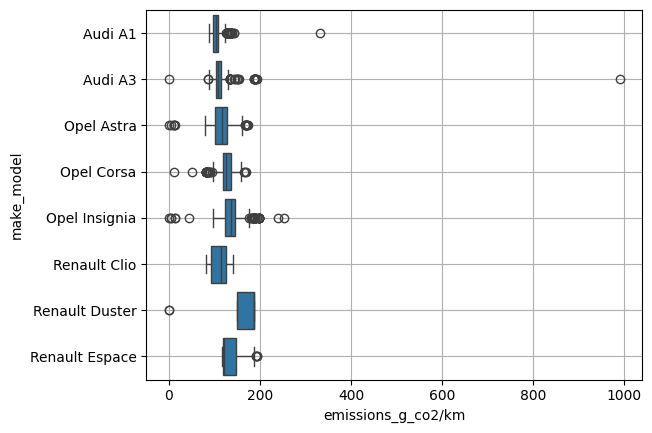

In [816]:
sns.boxplot(data=df_no_electric, x='emissions_g_co2/km', y='make_model').grid(True)

In [817]:
df.loc[((df['emissions_g_co2/km'] > 300) | (df['emissions_g_co2/km'] < 20)) & (df['fuel'] != 'Electric'), 'emissions_g_co2/km'] = np.nan

In [818]:
df['emissions_g_co2/km'].isna().sum()

np.int64(17)

In [819]:
eco2 = df['emissions_g_co2/km'].fillna(df.groupby(['make_model', 'fuel', 'displacement_cc', 'age_years'])['emissions_g_co2/km'].transform(lambda x: x.median()))

In [820]:
eco2.isna().sum()

np.int64(3)

In [821]:
eco2 = eco2.fillna(df.groupby(['make_model', 'fuel'])['emissions_g_co2/km'].transform(lambda x: x.median()))

In [822]:
eco2.isna().sum()

np.int64(0)

In [823]:
df['emissions_g_co2/km'] = eco2

### country_l_per_100km

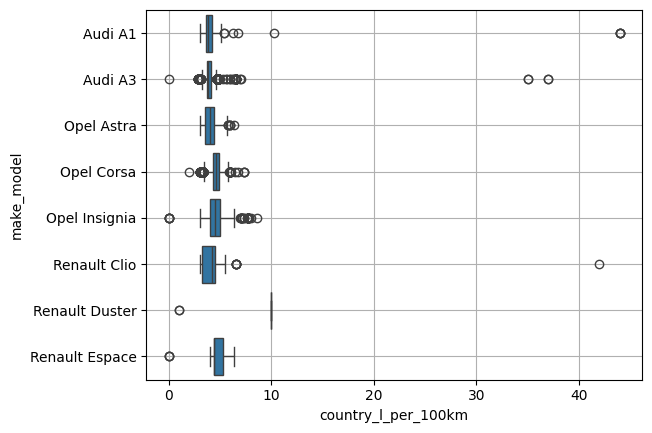

In [824]:
sns.boxplot(data=df_no_electric, x='country_l_per_100km', y='make_model').grid(True)

In [825]:
df.loc[((df['country_l_per_100km'] > 7.5) | (df['country_l_per_100km'] < 2.5)) & (df['fuel'] != 'Electric'), 'country_l_per_100km'] = np.nan

In [826]:
df['country_l_per_100km'].isna().sum()

np.int64(79)

In [827]:
country = df['country_l_per_100km'].fillna(df.groupby(['make_model', 'fuel', 'displacement_cc', 'age_years'])['country_l_per_100km'].transform(lambda x: x.median()))

In [828]:
country.isna().sum()

np.int64(36)

In [829]:
country = country.fillna(df.groupby(['displacement_cc'])['country_l_per_100km'].transform(lambda x: x.median()))

In [830]:
country.isna().sum()

np.int64(0)

In [831]:
df['country_l_per_100km'] = country

### city_l_per_100km

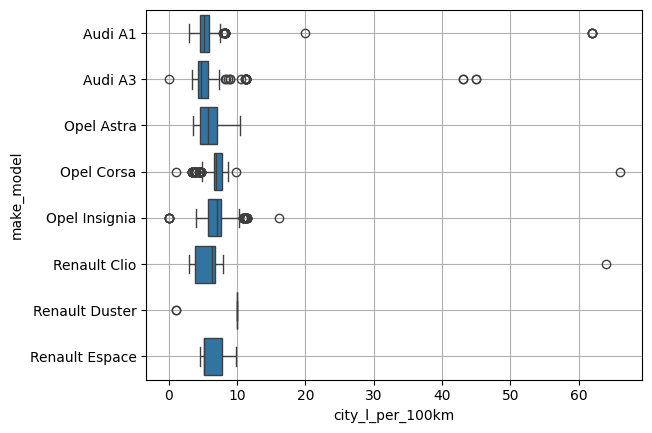

In [832]:
sns.boxplot(data=df_no_electric, x='city_l_per_100km', y='make_model').grid(True)

In [833]:
df.loc[((df['city_l_per_100km'] > 15) | (df['city_l_per_100km'] < 2.5)) & (df['fuel'] != 'Electric'), 'city_l_per_100km'] = np.nan

In [834]:
df['city_l_per_100km'].isna().sum()

np.int64(21)

In [835]:
city = df['city_l_per_100km'].fillna(df.groupby(['make_model', 'fuel', 'displacement_cc', 'age_years'])['city_l_per_100km'].transform(lambda x: x.median()))

In [836]:
city.isna().sum()

np.int64(3)

In [837]:
city = city.fillna(df.groupby(['fuel', 'displacement_cc'])['city_l_per_100km'].transform(lambda x: x.median()))

In [838]:
city.isna().sum()

np.int64(0)

In [839]:
df['city_l_per_100km'] = city

### combined_l_per_100km

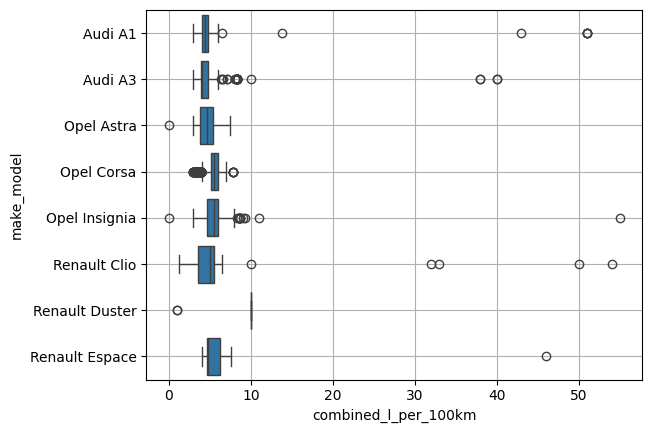

In [840]:
sns.boxplot(data=df_no_electric, x='combined_l_per_100km', y='make_model').grid(True)

In [841]:
comb_outliers = df_no_electric.groupby('make_model')['combined_l_per_100km'].transform(lambda x: get_outliers(x))

In [842]:
df.loc[((df['combined_l_per_100km'] > 10) | (df['combined_l_per_100km'] < 2)) & (df_no_electric['combined_l_per_100km'].isin(comb_outliers)), 'combined_l_per_100km'] = np.nan

In [843]:
df['combined_l_per_100km'].isna().sum()

np.int64(21)

In [844]:
comb = df['combined_l_per_100km'].fillna(df.groupby(['make_model', 'fuel', 'displacement_cc', 'age_years'])['combined_l_per_100km'].transform(lambda x: x.median()))

In [845]:
comb.isna().sum()

np.int64(3)

In [846]:
comb = comb.fillna(df.groupby(['make_model', 'fuel'])['combined_l_per_100km'].transform(lambda x: x.median()))

In [847]:
comb.isna().sum()

np.int64(0)

In [848]:
df['combined_l_per_100km'] = comb

### next_inspection

In [849]:
df['next_inspection'].value_counts(dropna=False)

next_inspection
2023-04    837
2021-06    823
2023-03    767
2023-02    740
2022-03    661
          ... 
2017-12      1
2023-08      1
2023-11      1
1921-01      1
2024-03      1
Name: count, Length: 83, dtype: int64

In [850]:
df['next_inspection_yyyymm'] = pd.to_datetime(df['next_inspection'], format='%Y-%m', errors='coerce').dt.strftime('%Y%m').astype(float)
df['next_inspection_yyyymm'].value_counts(dropna=False)

next_inspection_yyyymm
202304.0    837
202106.0    823
202303.0    767
202302.0    740
202203.0    661
           ... 
201712.0      1
202308.0      1
202311.0      1
192101.0      1
202403.0      1
Name: count, Length: 83, dtype: int64

In [851]:
df.drop(columns=['next_inspection'], inplace=True)

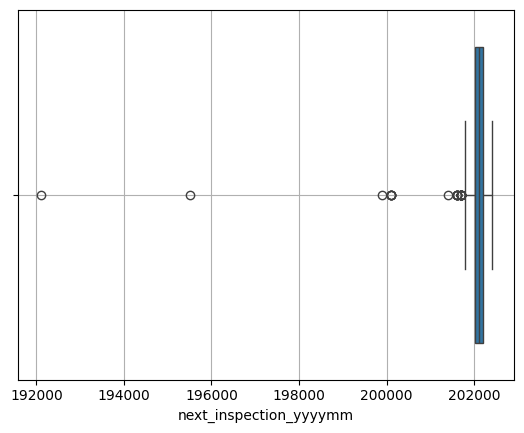

In [852]:
sns.boxplot(data=df, x='next_inspection_yyyymm').grid(True)

In [854]:
df.loc[(df['next_inspection_yyyymm'] < 202000), 'next_inspection_yyyymm'] = np.nan

In [855]:
df['next_inspection_yyyymm'].isna().sum()

np.int64(503)

In [856]:
ni = df['next_inspection_yyyymm'].astype(str).fillna(df.groupby(['make_model', 'age_years'])['next_inspection_yyyymm'].transform(lambda x: x.mode()[0] if not x.mode().empty else np.nan)).astype(float)

In [857]:
ni.isna().sum()

np.int64(0)

In [858]:
df['next_inspection_yyyymm'] = ni

## Export Data

In [863]:
df.to_csv('data/phase3_cleaned_data.csv', index=False)